# Installs

<li>pip install mne<li>
<li>pip install pandas<li>
<li>pip install numpy<li>
<li>pip install torch<li>
<li>pip install torcheeg<li>

In [105]:
import logging
import os
import random
import time
from mne.datasets import eegbci
import mne
import numpy as np
import torch
from torch.utils.data.dataloader import DataLoader
from matplotlib import pyplot as plt
import matplotlib as mplt
from torcheeg import transforms
#from torcheeg.datasets import MNEDataset
from torcheeg.model_selection import KFold
#from torcheeg.models import TSCeption
#from torcheeg.trainers import ClassificationTrainer

In [6]:
class CustomDataSet(BaseDataset):
    def __init__(self, io_path):
        self.dataset_constructor(io_path)
        super().__init__(io_path):
        
    def dataset_constructor(self,io_path)

SyntaxError: invalid syntax (3268950070.py, line 4)

In [10]:
edffiles=r"C:\Users\johan\Documents\Documents\School\advanced machine learning\PROJECT\BCI"
subjects_id=np.arange(1,5)
runs_id=np.arange(4,10)
paths=eegbci.load_data(subjects=subjects_id, runs=runs_id,path=edffiles, update_path=True)
paths

c:\Users\johan\Documents\Documents\School\advanced machine learning\torcheeg-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R05.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R07.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R09.edf'),
 WindowsPath('C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/

In [11]:
edffile=r'C:/Users/johan/Documents/Documents/School/advanced machine learning/PROJECT/BCI/MNE-eegbci-data/files/eegmmidb/1.0.0/S003/S003R03.edf'


raw=mne.io.read_raw_edf(edffile)
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [117]:
print("duration: ",raw.annotations.duration)
print("count: ",raw.annotations.count())
print("onset:  ",raw.annotations.onset)
print("channel names: ",raw.ch_names)
raw.annotations.to_data_frame()

duration:  [4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1
 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1 4.2 4.1]
count:  {'T0': 15, 'T1': 7, 'T2': 8}
onset:   [  0.    4.2   8.3  12.5  16.6  20.8  24.9  29.1  33.2  37.4  41.5  45.7
  49.8  54.   58.1  62.3  66.4  70.6  74.7  78.9  83.   87.2  91.3  95.5
  99.6 103.8 107.9 112.1 116.2 120.4]
channel names:  ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


,onset,duration,description
0,2009-08-12 16:15:00.000,4.2,T0
1,2009-08-12 16:15:04.200,4.1,T2
2,2009-08-12 16:15:08.300,4.2,T0
3,2009-08-12 16:15:12.500,4.1,T1
4,2009-08-12 16:15:16.600,4.2,T0
5,2009-08-12 16:15:20.800,4.1,T2
6,2009-08-12 16:15:24.900,4.2,T0
7,2009-08-12 16:15:29.100,4.1,T1
8,2009-08-12 16:15:33.200,4.2,T0
9,2009-08-12 16:15:37.400,4.1,T1


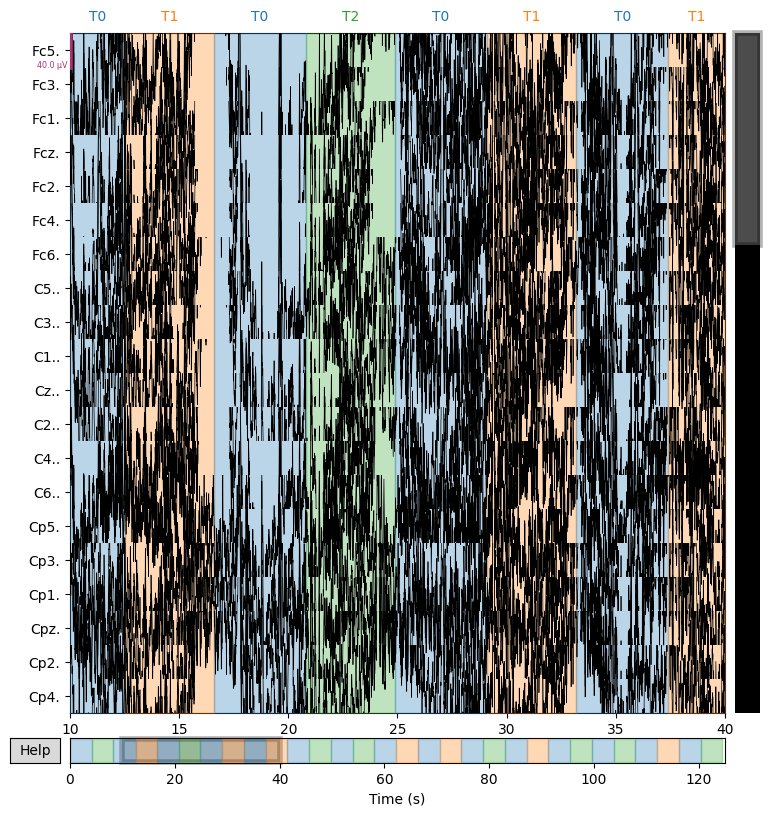

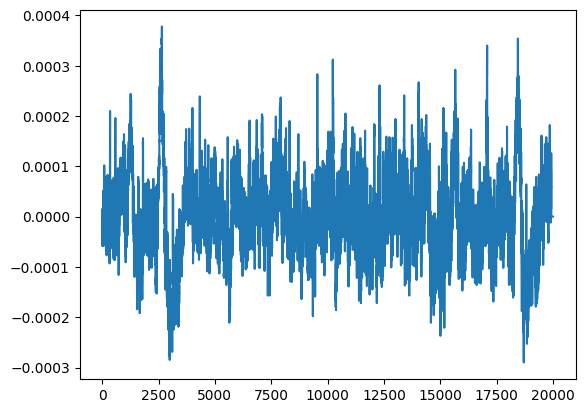

In [111]:
raw.plot(duration=30,start=10 ,bad_color="Red" )
first_ch=raw[0][0]
first_ch
plt.plot(first_ch[0])
plt.show()


20000

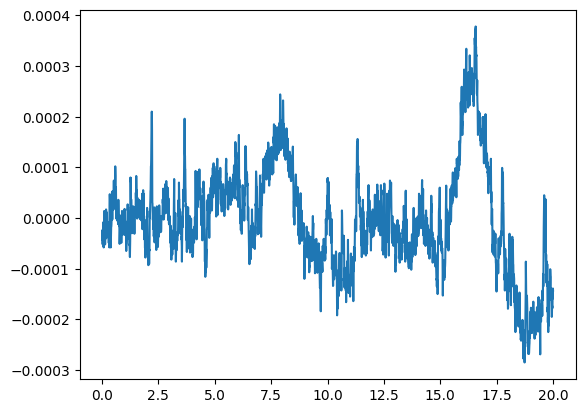

In [ ]:
data=raw.get_data()
ch_1=data[0]
hs=160
n=np.arange(1, 3201)
n=n/hs # set seconds
plt.plot(n,ch_1[:3200]) # first 20 seconds = 160 X 20
plt.show()